# Experimental diffusion notebook: LoRA training

Status: `experimental-diffusion`, not the stable-core API path.

Current implemented scope:
- generic registry-driven training API via `train_diffusion_lora(config=...)`
- `train_sd15_lora(...)` for `SD1.5` with `text2img`, `img2img`, `inpaint`
- `train_sdxl_lora(...)` for `SDXL` with `text2img`, `img2img`, `inpaint`, `refiner`
- `train_flux_lora(...)` as the first non-SD proof point with `text2img`
- local folder datasets, manifest datasets, and Hugging Face datasets
- family-owned LoRA target attachment/export strategies behind the generic core

Environment assumptions:
- `torch` + training dependencies installed
- usually CUDA/GPU and enough VRAM
- local dataset or manifest preparation is required for advanced tasks

Notebook policy: treat outputs as illustrative and re-check against `documentation/API_SURFACE.md` and `documentation/DIFFUSION_STATUS.md`.

# Обучение в YggDrasill

### Обучение LoRA модели

In [ ]:
# Как обучать LoRA модель на YggDrasill

# Текущая реализация в репозитории поддерживает generic diffusers-family training path через
# `yggdrasill.integrations.diffusers.training`.

# Публичные entrypoint сейчас такие:
# - `train_diffusion_lora(config=...)` как generic API
# - `train_sd15_lora(...)` для `SD1.5`
# - `train_sdxl_lora(...)` для `SDXL`
# - `train_flux_lora(...)` для proof-point `FLUX`

# Поддерживаемые tasks:
# - `SD1.5`: `text2img`, `img2img`, `inpaint`
# - `SDXL`: `text2img`, `img2img`, `inpaint`, `refiner`
# - `FLUX`: `text2img`

# Что можно использовать как датасет:
# - локальную папку с изображениями;
# - для простого `text2img` подписи в соседних `.txt` файлах;
# - `metadata.jsonl` / `metadata.csv` manifest для расширенных tasks;
# - Hugging Face dataset, если в `data_dir` передать dataset id.

# Для Hugging Face dataset можно дополнительно задать:
# - `dataset_split`, например `train`;
# - `dataset_config_name`, если у датасета есть несколько конфигураций.

# Нужное окружение:
# - `torch`, `diffusers`, `datasets`, `peft`, `torchvision`, `Pillow`.

# Базовый сценарий обучения:
# - выбрать `train_diffusion_lora(config=...)` или family-specific wrapper;
# - передать `data_dir`, `pretrained`, `output_path`, `task`;
# - для `img2img` / `inpaint` / `refiner` использовать manifest dataset с `init_image`, `mask_image`, `prompt_2`,
#   `aesthetic_score` по мере необходимости.

In [1]:
from yggdrasill.integrations.diffusers.training import TrainingConfig, train_diffusion_lora


config = TrainingConfig(
    pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0",
    data_dir="GrafikXxxxxxxYyyyyyyyyyy/Achoocation",
    output_path="artifacts/my_sdxl_lora.safetensors",
    family="sdxl",
    task="text2img",
    mixed_precision="fp16",
    resolution=1024,
    num_epochs=10,
    batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    max_train_steps=2000,
    lora_rank=32,
    lora_alpha=32,
    logging_steps=10,
    checkpoint_every_n_steps=250,
    train_text_encoder=True,
)

result = train_diffusion_lora(config=config)

/workspace/YggDrasill/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[yggdrasill][train] promoting runtime mixed precision from fp16 to bf16 for SDXL text-encoder LoRA stability


[yggdrasill] Loading components from stabilityai/stable-diffusion-xl-base-1.0: tokenizer, tokenizer_2, text_encoder, text_encoder_2, unet, vae, scheduler
[yggdrasill] Loading CLIPTokenizer from stabilityai/stable-diffusion-xl-base-1.0/tokenizer ...
[yggdrasill] Loaded CLIPTokenizer from stabilityai/stable-diffusion-xl-base-1.0/tokenizer
[yggdrasill] Loading CLIPTokenizer from stabilityai/stable-diffusion-xl-base-1.0/tokenizer_2 ...
[yggdrasill] Loaded CLIPTokenizer from stabilityai/stable-diffusion-xl-base-1.0/tokenizer_2
[yggdrasill] Loading CLIPTextModel from stabilityai/stable-diffusion-xl-base-1.0/text_encoder ...
[yggdrasill] Loaded CLIPTextModel from stabilityai/stable-diffusion-xl-base-1.0/text_encoder
[yggdrasill] Loading CLIPTextModelWithProjection from stabilityai/stable-diffusion-xl-base-1.0/text_encoder_2 ...
[yggdrasill] Loaded CLIPTextModelWithProjection from stabilityai/stable-diffusion-xl-base-1.0/text_encoder_2
[yggdrasill] Loading UNet2DConditionModel from stabilityai

[yggdrasill][train] step=10 loss=0.371426
[yggdrasill][train] step=20 loss=0.565320
[yggdrasill][train] step=30 loss=0.389975
[yggdrasill][train] step=40 loss=0.975626
[yggdrasill][train] step=50 loss=1.231217
[yggdrasill][train] step=60 loss=0.284836
[yggdrasill][train] step=70 loss=0.356082
[yggdrasill][train] step=80 loss=0.654244
[yggdrasill][train] step=90 loss=0.242477
[yggdrasill][train] step=100 loss=0.224144


### Проверка обученной LoRA

[yggdrasill] Loading components from stabilityai/stable-diffusion-xl-base-1.0: tokenizer, tokenizer_2, text_encoder, text_encoder_2, unet, vae, scheduler
[yggdrasill] Component cache hit: CLIPTokenizer from stabilityai/stable-diffusion-xl-base-1.0/tokenizer
[yggdrasill] Component cache hit: CLIPTokenizer from stabilityai/stable-diffusion-xl-base-1.0/tokenizer_2
[yggdrasill] Component cache hit: CLIPTextModel from stabilityai/stable-diffusion-xl-base-1.0/text_encoder
[yggdrasill] Component cache hit: CLIPTextModelWithProjection from stabilityai/stable-diffusion-xl-base-1.0/text_encoder_2
[yggdrasill] Component cache hit: UNet2DConditionModel from stabilityai/stable-diffusion-xl-base-1.0/unet
[yggdrasill] Component cache hit: AutoencoderKL from stabilityai/stable-diffusion-xl-base-1.0/vae
[yggdrasill] Component cache hit: EulerDiscreteScheduler from stabilityai/stable-diffusion-xl-base-1.0/scheduler
[yggdrasill] Loaded 7/7 components: tokenizer, tokenizer_2, text_encoder, text_encoder_2,

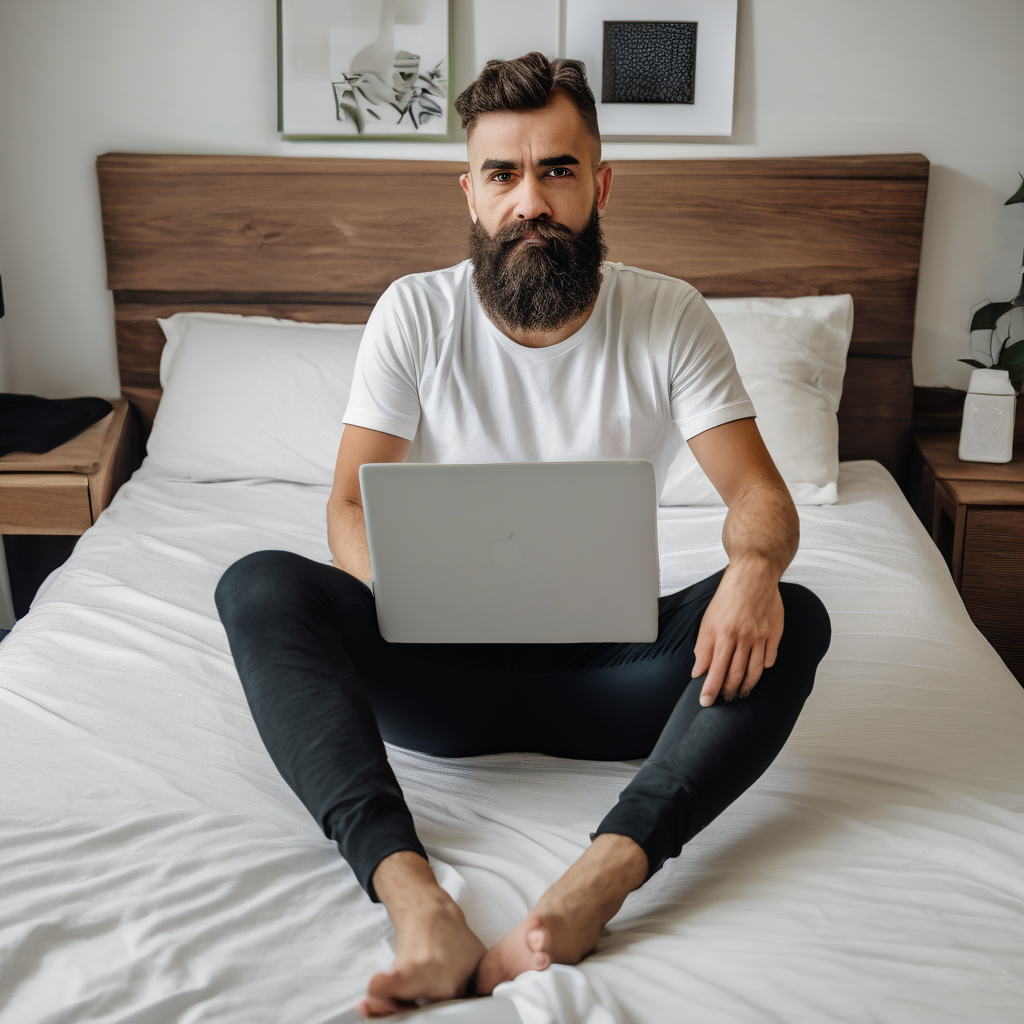

In [7]:
from yggdrasill import DiffusionGraphBuilder

base = DiffusionGraphBuilder.from_template("sdxl_text2img", device="cuda")
with_lora = DiffusionGraphBuilder.from_template("sdxl_text2img", device="cuda")
with_lora.add_component("lora", "sdxl.lora", pretrained="artifacts/my_sdxl_lora.safetensors")

common_kwargs = dict(
    prompt="Achoocation XJV523 is sitting on a bed with crossed legs, holding a laptop in his hands, looking into the camera, wearing a white T-shirt and a beard.",
    negative_prompt="blurry",
    num_inference_steps=50,
    guidance_scale=7.5,
    num_images_per_prompt=1,
    seed=42,
)

base_img = base.run(**common_kwargs).images[0]
lora_img = with_lora.run(
    **common_kwargs,
    lora_conditioning_scale=1.0,
).images[0]

base_img, lora_img